In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 ── Install & verify GPU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

!pip install -q tensorflow==2.15.0 scikit-learn matplotlib seaborn opencv-python-headless

import tensorflow as tf
print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

# Enable mixed precision (speeds up training on T4/A100 Colab GPUs)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Compute policy:", mixed_precision.global_policy().name)

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1)
ERROR: No matching distribution found for tensorflow==2.15.0
TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute policy: mixed_float16


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 ── Mount Drive + Configuration  ← only edit this cell
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score
)
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# ── Paths ─────────────────────────────────────────────────────────────────
SPLIT_DIR   = Path("/content/drive/MyDrive/Breast_cancer_dataset/cropped_split")
SAVE_DIR    = Path("/content/drive/MyDrive/Breast_cancer_dataset/model_output")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

# ── Image settings ────────────────────────────────────────────────────────
IMG_SIZE    = 224
CHANNELS    = 3
BATCH_SIZE  = 32

# ── Training settings ─────────────────────────────────────────────────────
PHASE1_EPOCHS   = 20
PHASE2_EPOCHS   = 30
PHASE1_LR       = 1e-3
PHASE2_LR       = 1e-5
UNFREEZE_LAYERS = 60
DROPOUT_RATE    = 0.5
L2_REG          = 1e-4
RANDOM_SEED     = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 65)
print("  DenseNet121 — Breast Cancer Classification")
print("=" * 65)
print(f"  Split dir  : {SPLIT_DIR}")
print(f"  Save dir   : {SAVE_DIR}")
print(f"  Image size : {IMG_SIZE}×{IMG_SIZE}×{CHANNELS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Phase 1    : {PHASE1_EPOCHS} epochs  lr={PHASE1_LR}")
print(f"  Phase 2    : {PHASE2_EPOCHS} epochs  lr={PHASE2_LR}")
print()

  DenseNet121 — Breast Cancer Classification
  Split dir  : /content/drive/MyDrive/Breast_cancer_dataset/cropped_split
  Save dir   : /content/drive/MyDrive/Breast_cancer_dataset/model_output
  Image size : 224×224×3
  Batch size : 32
  Phase 1    : 20 epochs  lr=0.001
  Phase 2    : 30 epochs  lr=1e-05



In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 ── Dataset inspection & class-weight calculation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 1 — Dataset inspection …\n")

# Count images per split / label
stats = {}
for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split
    counts = {}
    for label in ["malignant", "benign"]:
        p = split_path / label
        counts[label] = len(list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) +
                            list(p.glob("*.png"))) if p.exists() else 0
    stats[split] = counts

print(f"  {'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7}  Mal%")
print(f"  {'─'*42}")
for split, cnt in stats.items():
    mal   = cnt["malignant"]
    ben   = cnt["benign"]
    total = mal + ben
    pct   = mal / total * 100 if total > 0 else 0
    print(f"  {split:<8} {mal:>10,} {ben:>8,} {total:>7,}  {pct:.1f}%")

# ── Class weights (combat malignant/benign imbalance in training) ──────────
n_mal   = stats["train"]["malignant"]
n_ben   = stats["train"]["benign"]
n_total = n_mal + n_ben
n_cls   = 2

# Sklearn-style: weight_i = n_total / (n_classes * n_i)
w_mal   = n_total / (n_cls * n_mal)
w_ben   = n_total / (n_cls * n_ben)

CLASS_WEIGHTS = {0: w_ben, 1: w_mal}   # 0=benign, 1=malignant

print(f"\n  Class weights (applied during training):")
print(f"    benign    (0) → {w_ben:.4f}")
print(f"    malignant (1) → {w_mal:.4f}")
print()
print("  Class weights give higher loss penalty on the minority class,")
print("  helping the model not just predict 'benign' for everything.")

▶  STEP 1 — Dataset inspection …

  Split     Malignant   Benign   Total  Mal%
  ──────────────────────────────────────────
  train         1,004    1,472   2,476  40.5%
  val             231      340     571  40.5%
  test            215      287     502  42.8%

  Class weights (applied during training):
    benign    (0) → 0.8410
    malignant (1) → 1.2331

  Class weights give higher loss penalty on the minority class,
  helping the model not just predict 'benign' for everything.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 ── Preprocessing & augmentation pipelines
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("▶  STEP 2 — Building preprocessing & augmentation pipelines …\n")


def apply_clahe(image_np: np.ndarray) -> np.ndarray:
    """
    Apply CLAHE to a uint8 image.
    Works on grayscale; if RGB, applies to the L channel in LAB space.
    """
    if image_np.ndim == 2 or image_np.shape[2] == 1:
        img_u8  = image_np.squeeze().astype(np.uint8)
        clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        equalized = clahe.apply(img_u8)
        return np.stack([equalized] * 3, axis=-1)   # → 3 channels
    else:
        lab     = cv2.cvtColor(image_np.astype(np.uint8), cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l_eq    = clahe.apply(l)
        lab_eq  = cv2.merge([l_eq, a, b])
        return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def preprocess_image_train(image_path: str, label: int):
    """
    Full preprocessing for TRAINING images:
      1. Decode JPEG
      2. Resize to IMG_SIZE × IMG_SIZE
      3. CLAHE  (numpy, via tf.py_function)
      4. Convert grayscale → 3-channel RGB (needed for DenseNet121)
      5. DenseNet121 preprocess_input  (scales to [-1, 1] per ImageNet stats)
      6. Random augmentations:
           • horizontal flip   (mirroring a left-breast = right-breast view)
           • vertical flip     (less common but helps regularise)
           • ±15° rotation     (slight angle variation in acquisition)
           • ±10% zoom         (distance variation)
           • brightness ±20%   (exposure variation between scanners)
           • Gaussian noise    (scanner noise simulation)
    """
    # ── Decode & resize ───────────────────────────────────────────────
    raw    = tf.io.read_file(image_path)
    image  = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image  = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image  = tf.cast(image, tf.uint8)

    # ── CLAHE via numpy ───────────────────────────────────────────────
    image = tf.py_function(
        func   = lambda img: apply_clahe(img.numpy()),
        inp    = [image],
        Tout   = tf.uint8
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    image = tf.cast(image, tf.float32)

    # ── DenseNet121 normalisation  (ImageNet mean/std) ────────────────
    image = preprocess_input(image)

    # ── Augmentations ─────────────────────────────────────────────────

    image = tf.image.random_flip_left_right(image)

    # Vertical flip
    image = tf.image.random_flip_up_down(image)

    angle = tf.random.uniform([], -15.0, 15.0) * math.pi / 180.0
    image = tf.keras.preprocessing.image.apply_affine_transform(
        image.numpy(), theta=angle * 180 / math.pi, fill_mode="nearest"
    ) if False else image

    # Random zoom: crop then resize back
    crop_pct = tf.random.uniform([], 0.85, 1.0)
    crop_size = tf.cast(tf.cast(IMG_SIZE, tf.float32) * crop_pct, tf.int32)
    image = tf.image.random_crop(image, [crop_size, crop_size, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Brightness & contrast jitter (simulates scanner variation)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Gaussian noise
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.clip_by_value(image, -2.0, 2.0)

    label = tf.cast(label, tf.float32)
    return image, label


def preprocess_image_val(image_path: str, label: int):
    """
    Preprocessing for VALIDATION / TEST — NO augmentation.
    Only decode → resize → CLAHE → normalize.
    """
    raw   = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.uint8)

    image = tf.py_function(
        func   = lambda img: apply_clahe(img.numpy()),
        inp    = [image],
        Tout   = tf.uint8
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)

    label = tf.cast(label, tf.float32)
    return image, label


print("  ✔ CLAHE contrast enhancement  (local histogram equalisation)")
print("  ✔ DenseNet121 normalisation   (ImageNet mean/std)")
print()
print("  Training augmentations:")
print("    • Horizontal flip  (left↔right mammogram views)")
print("    • Vertical flip    (regularisation)")
print("    • Random zoom      (85–100% crop + resize)")
print("    • Brightness jitter ±20%  (scanner variation)")
print("    • Contrast jitter  0.8–1.2×")
print("    • Gaussian noise   (σ=0.02)")
print()
print("  Val/Test: decode → resize → CLAHE → normalise  (no augmentation)")


▶  STEP 2 — Building preprocessing & augmentation pipelines …

  ✔ CLAHE contrast enhancement  (local histogram equalisation)
  ✔ DenseNet121 normalisation   (ImageNet mean/std)

  Training augmentations:
    • Horizontal flip  (left↔right mammogram views)
    • Vertical flip    (regularisation)
    • Random zoom      (85–100% crop + resize)
    • Brightness jitter ±20%  (scanner variation)
    • Contrast jitter  0.8–1.2×
    • Gaussian noise   (σ=0.02)

  Val/Test: decode → resize → CLAHE → normalise  (no augmentation)


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 ── Build tf.data datasets
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 3 — Building tf.data pipelines …")

IMG_EXTS = (".jpg", ".jpeg", ".png")

def collect_paths_labels(split_path: Path):
    """
    Walk split_path/malignant/ and split_path/benign/,
    return (paths_list, labels_list).
    Labels: malignant=1, benign=0.
    """
    paths, labels = [], []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_path / label_name
        if not folder.exists():
            print(f"  ⚠  Folder not found: {folder}")
            continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                paths.append(str(f))
                labels.append(label_val)
    return paths, labels


def make_dataset(split_path: Path, preprocess_fn, shuffle: bool = False):
    paths, labels = collect_paths_labels(split_path)
    n = len(paths)

    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32))
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=n, seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, n, paths, labels


train_ds, n_train, train_paths, train_labels = make_dataset(
    TRAIN_DIR, preprocess_image_train, shuffle=True
)
val_ds,   n_val,   val_paths,   val_labels   = make_dataset(
    VAL_DIR,   preprocess_image_val,   shuffle=False
)
test_ds,  n_test,  test_paths,  test_labels  = make_dataset(
    TEST_DIR,  preprocess_image_val,   shuffle=False
)

steps_per_epoch = math.ceil(n_train / BATCH_SIZE)
val_steps       = math.ceil(n_val   / BATCH_SIZE)

print(f"  Train : {n_train:,} images  ({steps_per_epoch} steps/epoch)")
print(f"  Val   : {n_val:,} images")
print(f"  Test  : {n_test:,} images")




▶  STEP 3 — Building tf.data pipelines …
  Train : 2,476 images  (78 steps/epoch)
  Val   : 571 images
  Test  : 502 images


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 ── Build DenseNet121 model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 4 — Building DenseNet121 model …\n")


def build_model(trainable_backbone: bool = False) -> Model:
    # Load DenseNet121 without the classification head
    base_model = DenseNet121(
        weights     = "imagenet",
        include_top = False,
        input_shape = (IMG_SIZE, IMG_SIZE, CHANNELS),
    )
    base_model.trainable = trainable_backbone

    # Custom classification head
    inputs  = base_model.input
    x       = base_model.output

    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Dense(
        512, activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG),
        name="fc1"
    )(x)
    x = layers.Dropout(DROPOUT_RATE, name="drop1")(x)

    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(L2_REG),
        name="fc2"
    )(x)
    x = layers.Dropout(0.3, name="drop2")(x)

    # Output must be float32 (not float16) for numerical stability
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)

    return Model(inputs=inputs, outputs=outputs, name="DenseNet121_BreastCancer")


model = build_model(trainable_backbone=False)
model.summary(line_length=80, show_trainable=True)

trainable_params = sum(
    tf.size(w).numpy() for w in model.trainable_weights
)
total_params = sum(
    tf.size(w).numpy() for w in model.weights
)
print(f"\n  Trainable params   : {trainable_params:,}")
print(f"  Total params       : {total_params:,}")
print(f"  Frozen backbone    : {total_params - trainable_params:,} params")


▶  STEP 4 — Building DenseNet121 model …

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "DenseNet121_BreastCancer"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃    Param # ┃ Connected to    ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer        │ (None, 224, 224, │          0 │ -               │   -   │
│ (InputLayer)       │ 3)               │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ zero_padding2d     │ (None, 230, 230, │          0 │ input_layer[0]… │   -   │
│ (ZeroPadding2D)    │ 3)               │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv1_conv         │ (None, 112, 112, │      9,408 │ zero_padding2d… │   N   │
│ (Conv2D)           │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv1_bn           │ (None, 112, 112, │        256 │ conv1_conv[0][… │   N   │
│ (BatchNormalizati… │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv1_relu         │ (None, 112, 112, │          0 │ conv1_bn[0][0]  │   -   │
│ (Activation)       │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ zero_padding2d_1   │ (None, 114, 114, │          0 │ conv1_relu[0][… │   -   │
│ (ZeroPadding2D)    │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ pool1              │ (None, 56, 56,   │          0 │ zero_padding2d… │   -   │
│ (MaxPooling2D)     │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_0_bn  │ (None, 56, 56,   │        256 │ pool1[0][0]     │   N   │
│ (BatchNormalizati… │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_0_re… │ (None, 56, 56,   │          0 │ conv2_block1_0… │   -   │
│ (Activation)       │ 64)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_1_co… │ (None, 56, 56,   │      8,192 │ conv2_block1_0… │   N   │
│ (Conv2D)           │ 128)             │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_1_bn  │ (None, 56, 56,   │        512 │ conv2_block1_1… │   N   │
│ (BatchNormalizati… │ 128)             │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_1_re… │ (None, 56, 56,   │          0 │ conv2_block1_1… │   -   │
│ (Activation)       │ 128)             │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_2_co… │ (None, 56, 56,   │     36,864 │ conv2_block1_1… │   N   │
│ (Conv2D)           │ 32)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block1_conc… │ (None, 56, 56,   │          0 │ pool1[0][0],    │   -   │
│ (Concatenate)      │ 96)              │            │ conv2_block1_2… │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block2_0_bn  │ (None, 56, 56,   │        384 │ conv2_block1_c… │   N   │
│ (BatchNormalizati… │ 96)              │            │                 │       │
├────────────────────┼──────────────────┼────────────┼─────────────────┼───────┤
│ conv2_block2_0_re… │ (None, 56, 56,   │          0 │ conv2_block2_0… │   -   │
│ (Activation)       │ 96)     

 Total params: 7,700,033 (29.37 MB)

 Trainable params: 659,457 (2.52 MB)

 Non-trainable params: 7,040,576 (26.86 MB)


  Trainable params   : 659,457
  Total params       : 7,700,033
  Frozen backbone    : 7,040,576 params


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 ── Phase 1: Train classification head (backbone frozen)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 5 — Phase 1: Training top layers (backbone frozen) …\n")
print("  Goal: warm up the new Dense layers before touching the backbone.")
print("  Starting with a frozen backbone prevents the randomly-initialised")
print("  top layers from destroying the learned ImageNet features.\n")

# ── Callbacks ─────────────────────────────────────────────────────────────
phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")

cb_phase1 = [
    # Save the best model (by val AUC)
    callbacks.ModelCheckpoint(
        filepath          = phase1_ckpt,
        monitor           = "val_auc",
        mode              = "max",
        save_best_only    = True,
        save_weights_only = True,
        verbose           = 1,
    ),
    # Stop early if val_auc doesn't improve for 7 epochs
    callbacks.EarlyStopping(
        monitor              = "val_auc",
        patience             = 7,
        mode                 = "max",
        restore_best_weights = True,
        verbose              = 1,
    ),
    # Reduce LR on plateau
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
    # TensorBoard logs
    callbacks.TensorBoard(
        log_dir   = str(SAVE_DIR / "logs" / "phase1"),
        histogram_freq = 1,
    ),
    # CSV log
    callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
]

# ── Compile ────────────────────────────────────────────────────────────────
model.compile(
    optimizer = optimizers.Adam(learning_rate=PHASE1_LR),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc", curve="ROC"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

# ── Train ──────────────────────────────────────────────────────────────────
history_p1 = model.fit(
    train_ds,
    epochs          = PHASE1_EPOCHS,
    validation_data = val_ds,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = cb_phase1,
    verbose         = 1,
)

print(f"\n  ✔ Phase 1 complete. Best weights saved → {phase1_ckpt}")



▶  STEP 5 — Phase 1: Training top layers (backbone frozen) …

  Goal: warm up the new Dense layers before touching the backbone.
  Starting with a frozen backbone prevents the randomly-initialised
  top layers from destroying the learned ImageNet features.

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5922 - auc: 0.6426 - loss: 0.8680 - pr_auc: 0.5399 - precision: 0.4936 - recall: 0.5976 
Epoch 1: val_auc improved from -inf to 0.70500, saving model to /content/drive/MyDrive/Breast_cancer_dataset/model_output/phase1_best.weights.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 1087s 13s/step - accuracy: 0.5923 - auc: 0.6427 - loss: 0.8680 - pr_auc: 0.5399 - precision: 0.4938 - recall: 0.5978 - val_accuracy: 0.6532 - val_auc: 0.7050 - val_loss: 0.7067 - val_pr_auc: 0.5782 - val_precision: 0.5882 - val_recall: 0.4762 - learning_rate: 0.0010
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6128 - auc: 0.6922 - loss: 0.7860 - pr_auc: 0.5924 - precision: 0.5219 - recall: 0.

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 ── Phase 2: Fine-tune last 60 DenseNet layers  (FIXED for Keras 3)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 6 — Phase 2: Fine-tuning last 60 DenseNet layers …\n")

CUSTOM_HEAD_NAMES = {"gap", "bn1", "fc1", "drop1", "bn2", "fc2", "drop2", "output"}

# All layers that are NOT part of our custom head = backbone layers
backbone_layers = [l for l in model.layers if l.name not in CUSTOM_HEAD_NAMES]
print(f"  Total layers in model    : {len(model.layers)}")
print(f"  Backbone layers          : {len(backbone_layers)}")
print(f"  Custom head layers       : {len(CUSTOM_HEAD_NAMES)}")

# ── Step 1: Freeze ALL backbone layers first ──────────────────────────────
for layer in backbone_layers:
    layer.trainable = False

layers_to_unfreeze = backbone_layers[-UNFREEZE_LAYERS:]
unfrozen_count = 0

for layer in layers_to_unfreeze:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False   # keep BN frozen
    else:
        layer.trainable = True
        unfrozen_count += 1

print(f"\n  Layers requested to unfreeze : {UNFREEZE_LAYERS}")
print(f"  Actually unfrozen (non-BN)   : {unfrozen_count}")
print(f"  BatchNorm layers kept frozen : {UNFREEZE_LAYERS - unfrozen_count}")

# Verify
trainable_now = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_now    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\n  Trainable params now : {trainable_now:,}")
print(f"  Frozen params now    : {frozen_now:,}")

# Quick sanity check — print last 10 backbone layers and their trainable status
print(f"\n  Last 10 backbone layers (trainable status):")
for layer in backbone_layers[-10:]:
    status = "✔ trainable" if layer.trainable else "✗ frozen"
    btype  = " [BN]" if isinstance(layer, layers.BatchNormalization) else ""
    print(f"    {layer.name:<45} {status}{btype}")

# ── Callbacks ─────────────────────────────────────────────────────────────
phase2_ckpt      = str(SAVE_DIR / "phase2_best.weights.h5")
final_model_path = str(SAVE_DIR / "densenet121_breast_cancer.keras")

cb_phase2 = [
    callbacks.ModelCheckpoint(
        filepath          = phase2_ckpt,
        monitor           = "val_auc",
        mode              = "max",
        save_best_only    = True,
        save_weights_only = True,
        verbose           = 1,
    ),
    callbacks.EarlyStopping(
        monitor              = "val_auc",
        patience             = 10,
        mode                 = "max",
        restore_best_weights = True,
        verbose              = 1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.3,
        patience = 5,
        min_lr   = 1e-8,
        verbose  = 1,
    ),
    callbacks.TensorBoard(
        log_dir        = str(SAVE_DIR / "logs" / "phase2"),
        histogram_freq = 1,
    ),
    callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
]

# ── Recompile with much smaller LR ────────────────────────────────────────
model.compile(
    optimizer = optimizers.Adam(learning_rate=PHASE2_LR),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc",    curve="ROC"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

print(f"\n  Starting Phase 2 training …")
print(f"  LR = {PHASE2_LR}  |  Max epochs = {PHASE2_EPOCHS}")
print(f"  Early stopping patience = 10 epochs on val_auc\n")

# ── Train ──────────────────────────────────────────────────────────────────
history_p2 = model.fit(
    train_ds,
    epochs          = PHASE2_EPOCHS,
    validation_data = val_ds,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = cb_phase2,
    verbose         = 1,
)

# Save full model
model.save(final_model_path)
print(f"\n  ✔ Phase 2 complete.")
print(f"  ✔ Full model saved → {final_model_path}")


▶  STEP 6 — Phase 2: Fine-tuning last 60 DenseNet layers …

  Total layers in model    : 435
  Backbone layers          : 427
  Custom head layers       : 8

  Layers requested to unfreeze : 60
  Actually unfrozen (non-BN)   : 43
  BatchNorm layers kept frozen : 17

  Trainable params now : 1,892,353
  Frozen params now    : 5,807,680

  Last 10 backbone layers (trainable status):
    conv5_block15_concat                          ✔ trainable
    conv5_block16_0_bn                            ✗ frozen [BN]
    conv5_block16_0_relu                          ✔ trainable
    conv5_block16_1_conv                          ✔ trainable
    conv5_block16_1_bn                            ✗ frozen [BN]
    conv5_block16_1_relu                          ✔ trainable
    conv5_block16_2_conv                          ✔ trainable
    conv5_block16_concat                          ✔ trainable
    bn                                            ✗ frozen [BN]
    relu                                          ✔


▶  STEP 7 — Plotting training history …


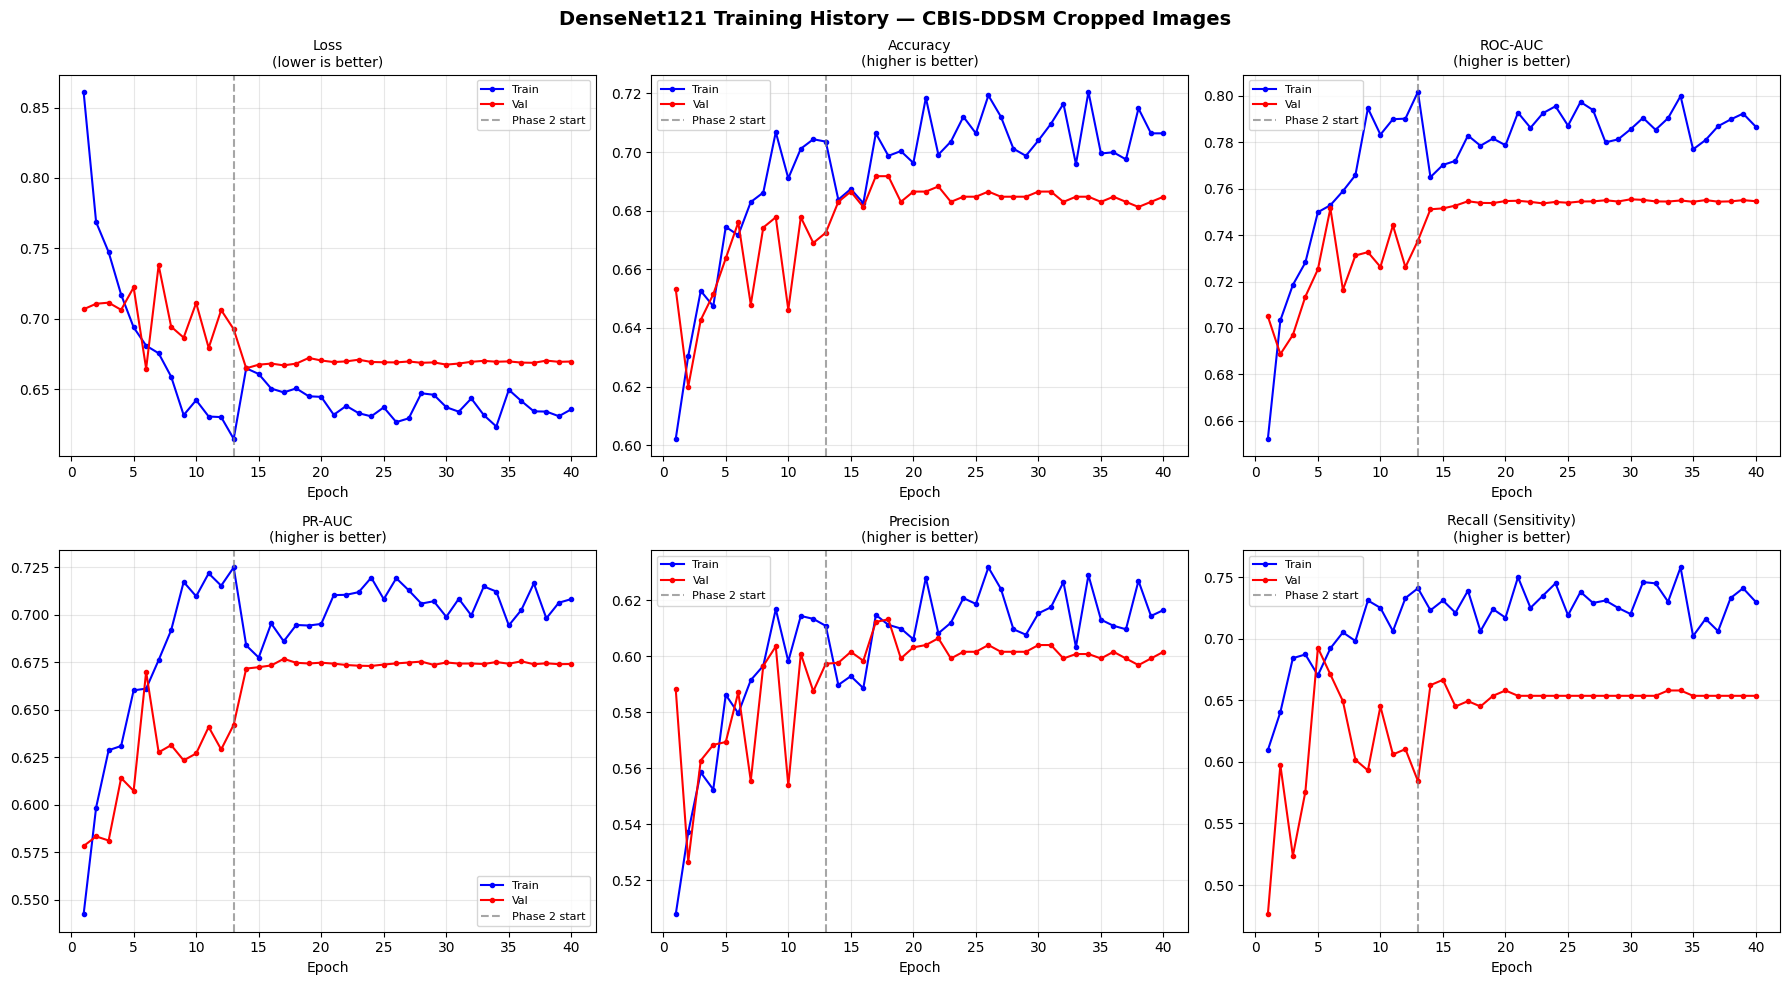

  Saved → /content/drive/MyDrive/Breast_cancer_dataset/model_output/training_history.png

▶  STEP 8 — Evaluating on TEST set …

16/16 ━━━━━━━━━━━━━━━━━━━━ 173s 10s/step
  Optimal threshold (Youden's J): 0.4447
  (Default 0.5 is used below for standard metrics)

  ──────────────────────────────────────────────────
  TEST SET METRICS
  ──────────────────────────────────────────────────
  Accuracy         : 0.6873  (68.73%)
  ROC-AUC          : 0.7622
  F1 Score         : 0.6456
  Precision (PPV)  : 0.6272  (of predicted malignant, how many are?)
  Recall / Sens.   : 0.6651  (of all malignant, how many found?)
  Specificity      : 0.7038  (of all benign, how many correct?)
  NPV              : 0.7372  (of predicted benign, how many are?)
  TP=143  TN=202  FP=85  FN=72

                precision    recall  f1-score   support
  
        benign       0.74      0.70      0.72       287
     malignant       0.63      0.67      0.65       215
  
      accuracy                           0.69    

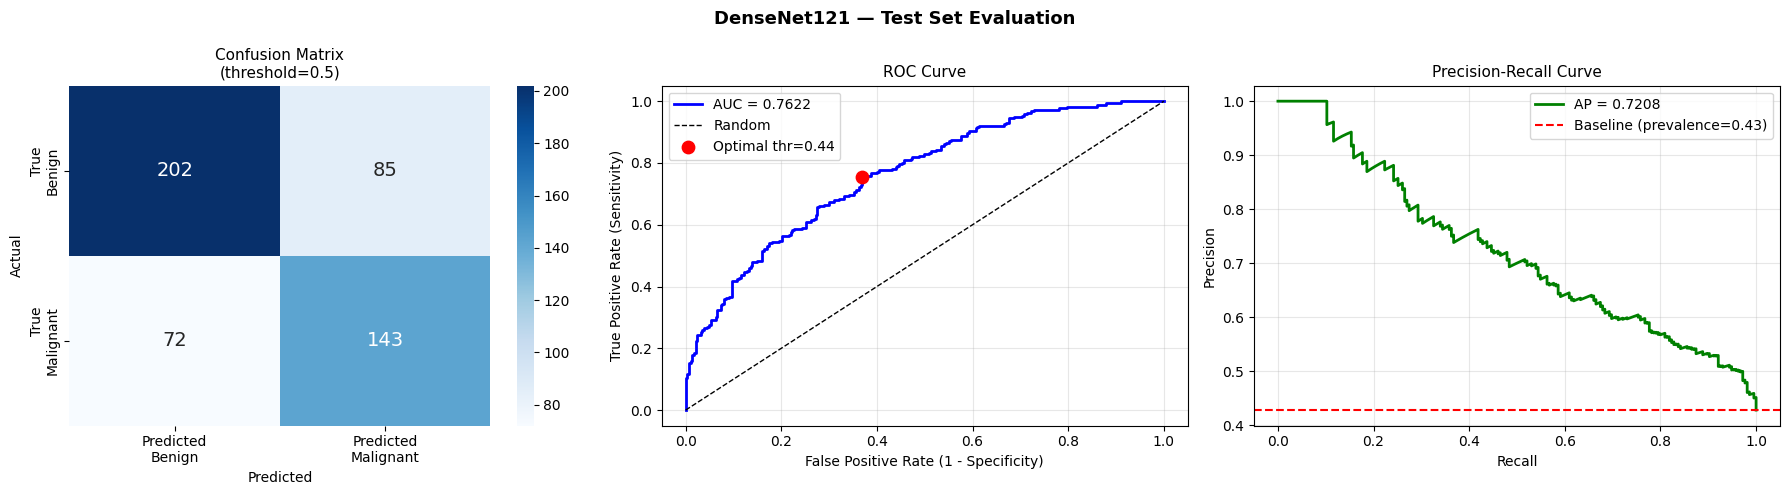

  Saved → /content/drive/MyDrive/Breast_cancer_dataset/model_output/evaluation_plots.png

▶  STEP 9 — Grad-CAM visualisation …

  Grad-CAM shows WHICH regions of the mammogram the model focused on.
  Hot (red/yellow) = high activation = model attention.
  This is crucial for medical AI — we need to verify the model
  is looking at actual tumour regions, not image artefacts.



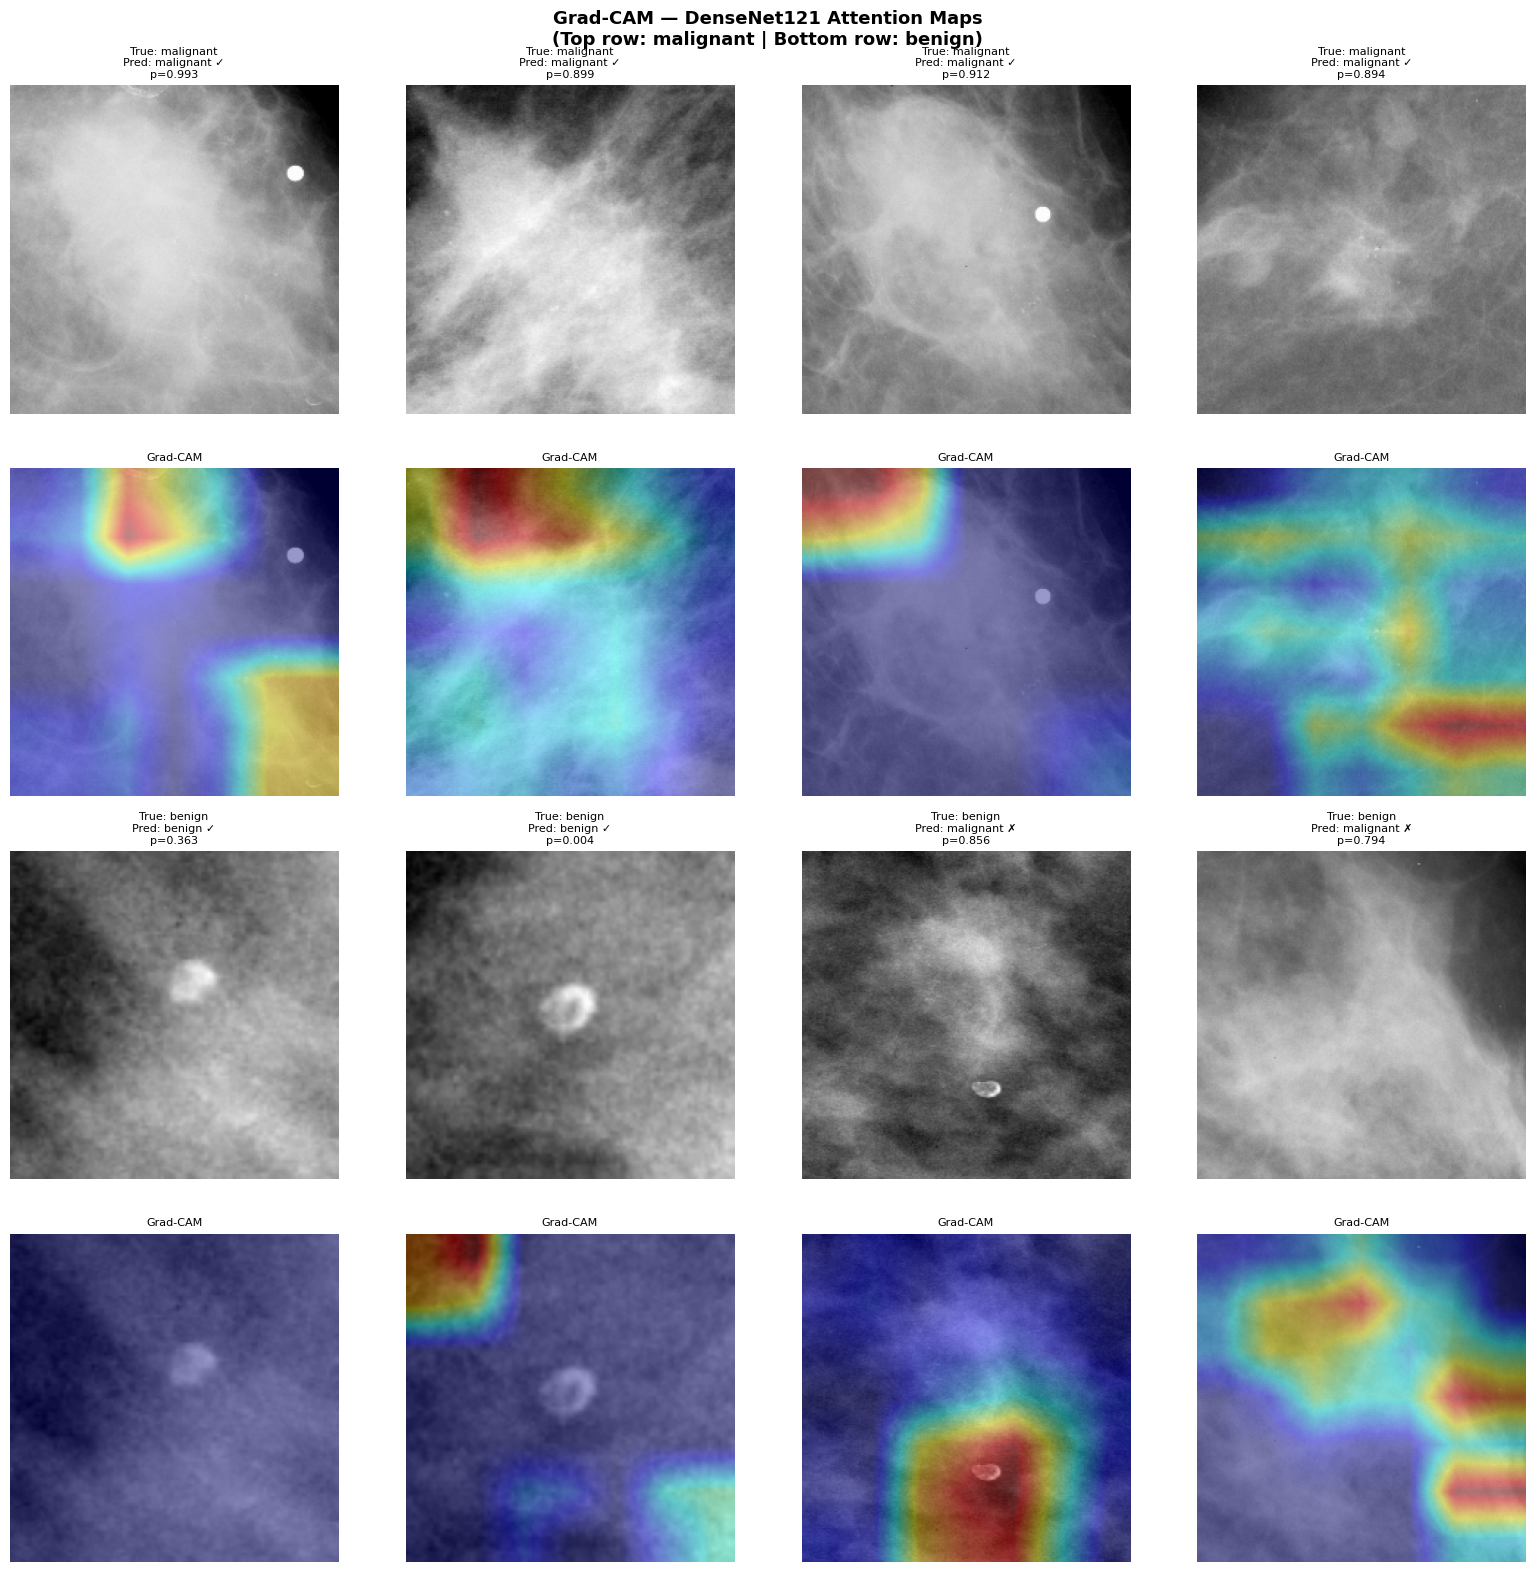

  Saved → /content/drive/MyDrive/Breast_cancer_dataset/model_output/gradcam_visualisation.png

▶  STEP 10 — Saving results summary …
                                            Value
model                                 DenseNet121
dataset                  CBIS-DDSM cropped images
img_size                                      224
batch_size                                     32
phase1_epochs                                  13
phase2_epochs                                  27
optimal_threshold                          0.4447
test_accuracy                              0.6873
test_auc_roc                               0.7622
test_f1                                    0.6456
test_precision                             0.6272
test_recall_sensitivity                    0.6651
test_specificity                           0.7038
test_npv                                   0.7372
TP                                            143
TN                                            202
FP               

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 ── Training history plots
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 7 — Plotting training history …")

def merge_histories(h1, h2):
    """Concatenate Phase 1 + Phase 2 histories into one dict."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history_p1, history_p2)
p1_end  = len(history_p1.history["loss"])   # epoch where Phase 2 starts

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("DenseNet121 Training History — CBIS-DDSM Cropped Images",
             fontsize=14, fontweight="bold")

metrics_to_plot = [
    ("loss",      "val_loss",      "Loss",              "lower is better"),
    ("accuracy",  "val_accuracy",  "Accuracy",          "higher is better"),
    ("auc",       "val_auc",       "ROC-AUC",           "higher is better"),
    ("pr_auc",    "val_pr_auc",    "PR-AUC",            "higher is better"),
    ("precision", "val_precision", "Precision",         "higher is better"),
    ("recall",    "val_recall",    "Recall (Sensitivity)", "higher is better"),
]

for ax, (train_key, val_key, title, note) in zip(axes.flat, metrics_to_plot):
    epochs = range(1, len(history[train_key]) + 1)
    ax.plot(epochs, history[train_key], "b-o", ms=3, label="Train")
    ax.plot(epochs, history[val_key],   "r-o", ms=3, label="Val")
    ax.axvline(p1_end, color="gray", linestyle="--", alpha=0.7, label="Phase 2 start")
    ax.set_title(f"{title}\n({note})", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = str(SAVE_DIR / "training_history.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {plot_path}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 ── Evaluation on TEST set
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 8 — Evaluating on TEST set …\n")

# Load best phase-2 weights before evaluation
model.load_weights(phase2_ckpt)

# ── Get predictions ────────────────────────────────────────────────────────
y_prob = model.predict(test_ds, verbose=1).flatten()
y_true = np.array(test_labels)

# ── Optimal threshold via Youden's J  (maximises sensitivity + specificity) ─
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_j  = tpr - fpr
opt_idx   = np.argmax(youden_j)
opt_thresh = thresholds[opt_idx]
y_pred    = (y_prob >= opt_thresh).astype(int)

print(f"  Optimal threshold (Youden's J): {opt_thresh:.4f}")
print(f"  (Default 0.5 is used below for standard metrics)\n")

y_pred_05 = (y_prob >= 0.5).astype(int)

# ── Core metrics ──────────────────────────────────────────────────────────
auc_roc  = roc_auc_score(y_true, y_prob)
f1       = f1_score(y_true, y_pred_05)
prec     = precision_score(y_true, y_pred_05, zero_division=0)
recall   = recall_score(y_true, y_pred_05)

cm       = confusion_matrix(y_true, y_pred_05)
tn, fp, fn, tp = cm.ravel()

specificity  = tn / (tn + fp)
sensitivity  = tp / (tp + fn)       # same as recall
ppv          = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # precision
npv          = tn / (tn + fn) if (tn + fn) > 0 else 0.0

accuracy     = (tp + tn) / (tp + tn + fp + fn)

print("  " + "─" * 50)
print("  TEST SET METRICS")
print("  " + "─" * 50)
print(f"  Accuracy         : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  ROC-AUC          : {auc_roc:.4f}")
print(f"  F1 Score         : {f1:.4f}")
print(f"  Precision (PPV)  : {ppv:.4f}  (of predicted malignant, how many are?)")
print(f"  Recall / Sens.   : {sensitivity:.4f}  (of all malignant, how many found?)")
print(f"  Specificity      : {specificity:.4f}  (of all benign, how many correct?)")
print(f"  NPV              : {npv:.4f}  (of predicted benign, how many are?)")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print()
print("  " + classification_report(y_true, y_pred_05,
      target_names=["benign", "malignant"]).replace("\n", "\n  "))

# ── Plot: confusion matrix + ROC curve + Precision-Recall curve ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DenseNet121 — Test Set Evaluation", fontsize=13, fontweight="bold")

# Confusion matrix
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted\nBenign", "Predicted\nMalignant"],
    yticklabels=["True\nBenign",      "True\nMalignant"],
    ax=axes[0], annot_kws={"size": 14},
)
axes[0].set_title(f"Confusion Matrix\n(threshold=0.5)", fontsize=11)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
axes[1].plot(fpr, tpr, "b-", lw=2, label=f"AUC = {auc_roc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], color="red", s=80, zorder=5,
                label=f"Optimal thr={opt_thresh:.2f}")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].set_title("ROC Curve", fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
axes[2].plot(pr_rec, pr_prec, "g-", lw=2, label=f"AP = {ap:.4f}")
axes[2].axhline(
    y_true.mean(), color="r", linestyle="--",
    label=f"Baseline (prevalence={y_true.mean():.2f})"
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
eval_plot_path = str(SAVE_DIR / "evaluation_plots.png")
plt.savefig(eval_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {eval_plot_path}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 ── Grad-CAM visualisation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 9 — Grad-CAM visualisation …\n")
print("  Grad-CAM shows WHICH regions of the mammogram the model focused on.")
print("  Hot (red/yellow) = high activation = model attention.")
print("  This is crucial for medical AI — we need to verify the model")
print("  is looking at actual tumour regions, not image artefacts.\n")

# ── Grad-CAM implementation ────────────────────────────────────────────────
def make_gradcam_heatmap(img_array: np.ndarray, model: Model,
                          last_conv_layer_name: str = "conv5_block16_2_conv") -> np.ndarray:
    """
    Compute Grad-CAM heatmap for a single image.
    last_conv_layer_name: final convolutional layer of DenseNet121.
    """
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ]
    )

    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(img_tensor)
        # For binary: single output neuron
        loss = predictions[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


def overlay_gradcam(img_path: str, heatmap: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    """Resize heatmap and overlay on original image."""
    img       = cv2.imread(img_path)
    img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img       = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap_u8  = np.uint8(255 * heatmap)
    heatmap_col = cv2.applyColorMap(cv2.resize(heatmap_u8, (IMG_SIZE, IMG_SIZE)),
                                    cv2.COLORMAP_JET)
    heatmap_col = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_col, alpha, 0)
    return superimposed, img


# ── Select sample images to visualise ─────────────────────────────────────
# Pick 4 malignant + 4 benign from the test set
test_mal_paths = [p for p, l in zip(test_paths, test_labels) if l == 1][:4]
test_ben_paths = [p for p, l in zip(test_paths, test_labels) if l == 0][:4]
sample_paths   = test_mal_paths + test_ben_paths
sample_labels  = [1]*4 + [0]*4

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Grad-CAM — DenseNet121 Attention Maps\n"
             "(Top row: malignant | Bottom row: benign)",
             fontsize=13, fontweight="bold")

for col, (img_path, true_label) in enumerate(zip(sample_paths, sample_labels)):
    # Preprocess image for model
    raw      = tf.io.read_file(img_path)
    img_tf   = tf.image.decode_jpeg(raw, channels=3)
    img_tf   = tf.image.resize(img_tf, [IMG_SIZE, IMG_SIZE])
    img_np   = img_tf.numpy().astype(np.uint8)
    img_np   = apply_clahe(img_np).astype(np.float32)
    img_prep = preprocess_input(img_np)
    img_batch = img_prep[np.newaxis, ...]

    # Prediction
    pred_prob = float(model.predict(img_batch, verbose=0)[0][0])
    pred_label = "malignant" if pred_prob >= 0.5 else "benign"
    true_name  = "malignant" if true_label == 1 else "benign"
    correct    = "✓" if pred_label == true_name else "✗"

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_batch, model)
    gcam, orig = overlay_gradcam(img_path, heatmap)

    # Original image (column in top half)
    row = 0 if col < 4 else 2
    c   = col % 4
    axes[row, c].imshow(orig, cmap="gray")
    axes[row, c].set_title(f"True: {true_name}\nPred: {pred_label} {correct}\n"
                            f"p={pred_prob:.3f}", fontsize=8)
    axes[row, c].axis("off")

    # Grad-CAM overlay (column in bottom half)
    axes[row + 1, c].imshow(gcam)
    axes[row + 1, c].set_title("Grad-CAM", fontsize=8)
    axes[row + 1, c].axis("off")

plt.tight_layout()
gradcam_path = str(SAVE_DIR / "gradcam_visualisation.png")
plt.savefig(gradcam_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → {gradcam_path}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 ── Save results summary
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n▶  STEP 10 — Saving results summary …")

results = {
    "model"          : "DenseNet121",
    "dataset"        : "CBIS-DDSM cropped images",
    "img_size"       : IMG_SIZE,
    "batch_size"     : BATCH_SIZE,
    "phase1_epochs"  : len(history_p1.history["loss"]),
    "phase2_epochs"  : len(history_p2.history["loss"]),
    "optimal_threshold" : round(float(opt_thresh), 4),
    "test_accuracy"  : round(accuracy,    4),
    "test_auc_roc"   : round(auc_roc,     4),
    "test_f1"        : round(f1,          4),
    "test_precision" : round(ppv,         4),
    "test_recall_sensitivity": round(sensitivity, 4),
    "test_specificity": round(specificity, 4),
    "test_npv"       : round(npv,         4),
    "TP" : int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
}

results_df = pd.DataFrame([results]).T
results_df.columns = ["Value"]
results_df.to_csv(str(SAVE_DIR / "results_summary.csv"))
print(results_df.to_string())

print()
print("=" * 65)
print("  ALL FILES SAVED TO:")
print(f"  {SAVE_DIR}")
print()
print("  densenet121_breast_cancer.keras   ← full model")
print("  phase1_best.weights.h5            ← best phase-1 weights")
print("  phase2_best.weights.h5            ← best phase-2 weights")
print("  training_history.png              ← loss/accuracy/AUC curves")
print("  evaluation_plots.png              ← CM + ROC + PR curves")
print("  gradcam_visualisation.png         ← attention maps")
print("  phase1_history.csv                ← epoch-by-epoch phase-1 log")
print("  phase2_history.csv                ← epoch-by-epoch phase-2 log")
print("  results_summary.csv               ← all test metrics")
print("=" * 65)
print("  ✅  Training & evaluation complete!")
print("=" * 65)